In [16]:
import pandas as pd

# Load the financial dataset
financial_df = pd.read_csv("finanical_report_2018.csv")

# Step 1a: Identify missing and non-numeric values
missing_or_invalid = financial_df.isnull() | ~financial_df.applymap(lambda x: isinstance(x, (int, float)))

# Extract stock codes and problematic feature names
invalid_entries = []
for idx, row in missing_or_invalid.iterrows():
    for col, is_invalid in row.items():
        if is_invalid:
            invalid_entries.append((financial_df.loc[idx, 'Stock Code'], col))

# Create a DataFrame to display the issues
invalid_df = pd.DataFrame(invalid_entries, columns=["Stock Code", "Feature with Issue"])
print("Missing or Invalid Values Detected:\n")
print(invalid_df)

'''
Task 1(a): Explanation - Identifying Missing or Invalid Values

To identify missing or invalid values in the dataset, the following method was used:

1. Used `.isnull()` to identify missing (NaN) values.
2. Used a lambda function with `applymap()` to detect non-numeric types.
3. Combined the results using a logical OR.
4. Collected and printed the stock codes and column names where issues exist.
'''

# Step 1(c): Replace missing values (use mean if not skewed, else use median)

numeric_cols = financial_df.select_dtypes(include=['float64', 'int64']).columns

Missing or Invalid Values Detected:

      Stock Code Feature with Issue
0         900939               Size
1         900956               Size
2         900952               Size
3         900933               Size
4         900957               Size
...          ...                ...
3868      600602               Size
3869      300146               Size
3870         811               Size
3871        2399               Size
3872      600393               Size

[3873 rows x 2 columns]


/var/folders/93/6lxt1ycx0k90y4b6w616bg0r0000gn/T/ipykernel_3965/3668632942.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  missing_or_invalid = financial_df.isnull() | ~financial_df.applymap(lambda x: isinstance(x, (int, float)))


In [17]:
# Step 1(c): Replace missing values (use mean if not skewed, else use median)
numeric_cols = financial_df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    if financial_df[col].isnull().sum() > 0:
        skewness = financial_df[col].skew()
        if abs(skewness) > 1:
            replacement_value = financial_df[col].median()
        else:
            replacement_value = financial_df[col].mean()
        financial_df[col].fillna(replacement_value, inplace=True)

# Verify all missing values are handled
assert financial_df[numeric_cols].isnull().sum().sum() == 0, "There are still missing values."

# Save cleaned dataset
financial_df.to_csv("cleaned_dataset.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_dataset.csv'")



Cleaned dataset saved as 'cleaned_dataset.csv'


/var/folders/93/6lxt1ycx0k90y4b6w616bg0r0000gn/T/ipykernel_3965/1982161886.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  financial_df[col].fillna(replacement_value, inplace=True)


In [18]:
# Task 2(a): Calculating two new feature values for each company

import pandas as pd  # Import pandas for data handling

# Load the cleaned dataset from Task 1
df = pd.read_csv("cleaned_dataset.csv")  # Read the CSV file into a DataFrame

# --- Step 1: Calculate V/P ratio using the provided formula ---

# Calculate the numerator part of the V/P formula
vp_numerator = (
    (1 - 1.24 * 0.12) * df['Book Value'] +                          # Weighted Book Value
    1.24 * 1.12 * df['Operating Income after Depreciation'] -      # Weighted Operating Income
    1.24 * 0.12 * df['Annual Dividends']                           # Weighted Annual Dividends
)

# Denominator is the Market Value of Equity
vp_denominator = df['Market Value of Equity']

# Compute the V/P feature and store it in a new column
df['V/P'] = vp_numerator / vp_denominator
print("V/P values added as a new column.")

# Preview first 5 values for verification
print("\nSample V/P values:")
print(df[['Stock Code', 'V/P']].head())


# Step 2: Calculate Investment_2018 using the provided formula 

# Subtract amortization and depreciation from total investment expenditure
df['Investment_2018'] = df['Total Investment Expenditure'] - df['Amortization and Depreciation']

# Preview first 5 values for verification
print("\nSample Investment_2018 values:")
print(df[['Stock Code', 'Investment_2018']].head())

# Save the updated DataFrame back to the same file
df.to_csv("cleaned_dataset.csv", index=False)  # Overwrite the file
print("\nOverwritten 'cleaned_dataset.csv' with new features included.")

V/P values added as a new column.

Sample V/P values:
   Stock Code       V/P
0      900939  0.357077
1      900956  0.528143
2      900952  0.597518
3      900933  0.482893
4      900957  0.481323

Sample Investment_2018 values:
   Stock Code  Investment_2018
0      900939       207.321400
1      900956       662.503500
2      900952       801.191621
3      900933     10224.290050
4      900957       276.220800

Overwritten 'cleaned_dataset.csv' with new features included.


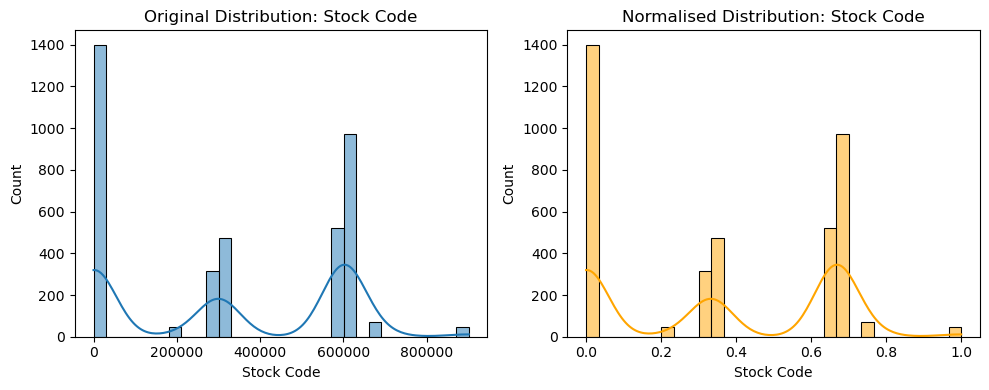

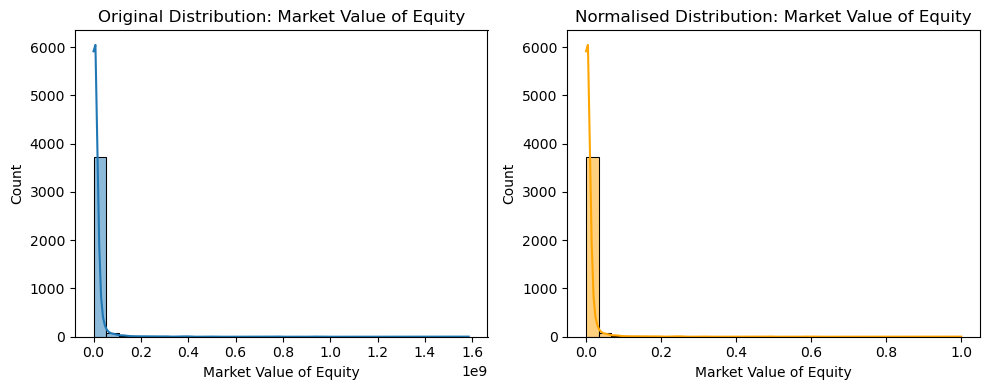

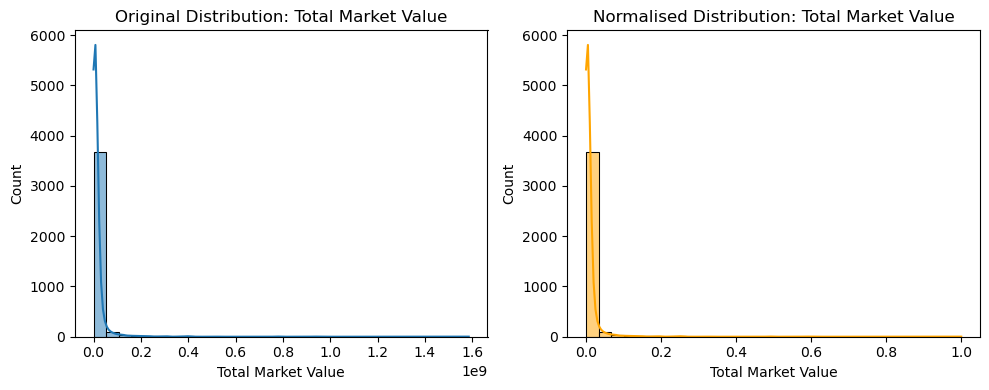

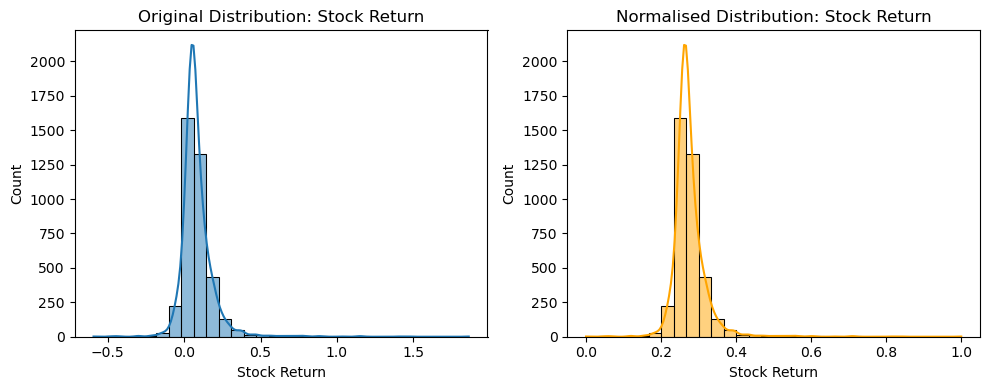

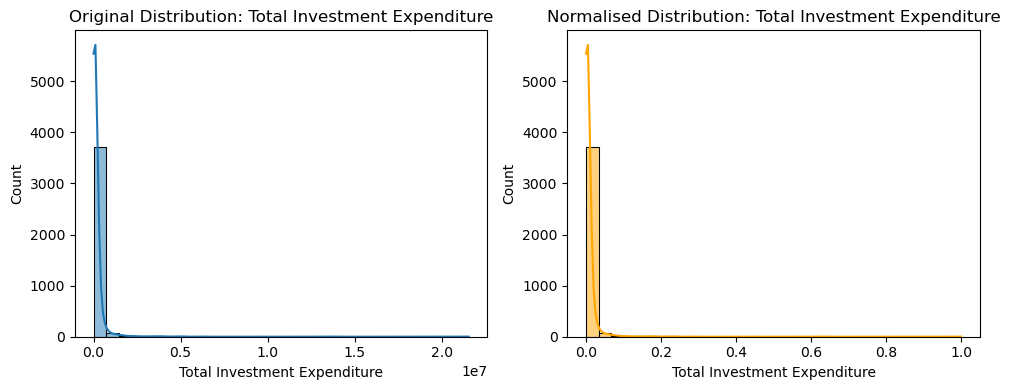

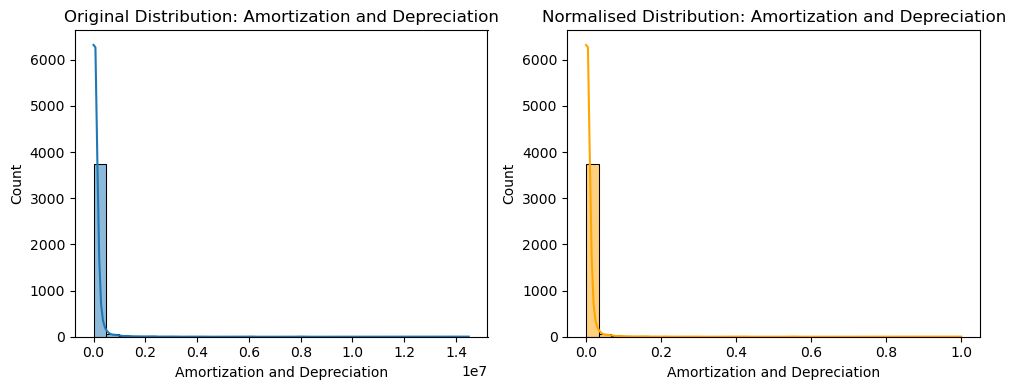

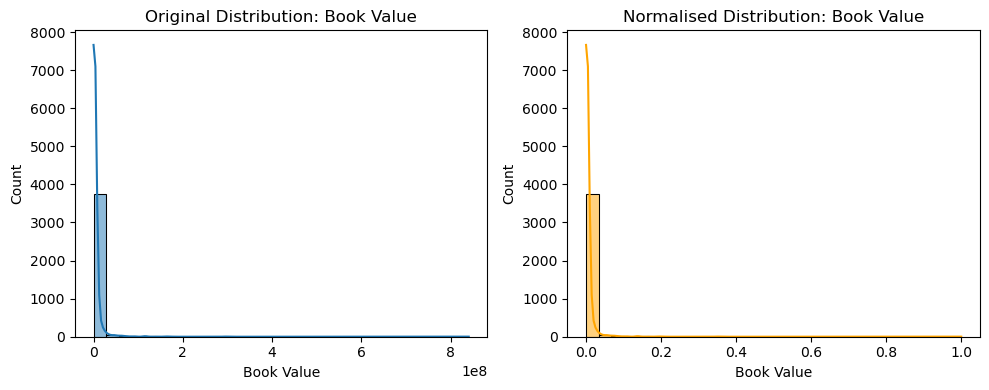

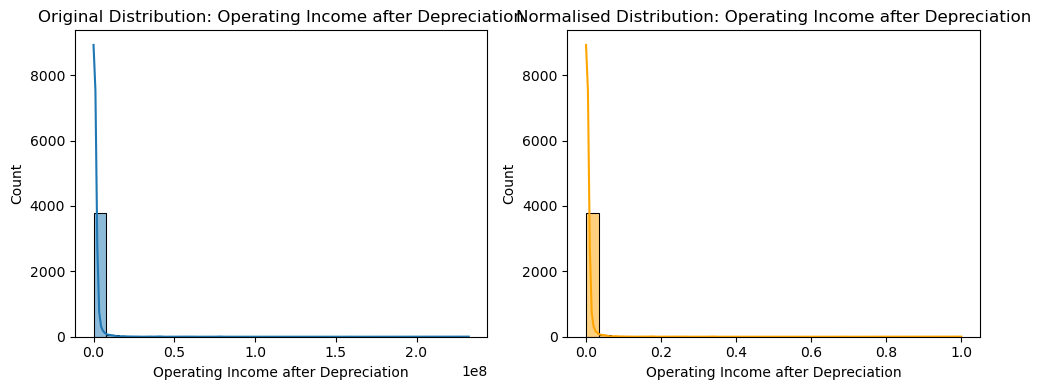

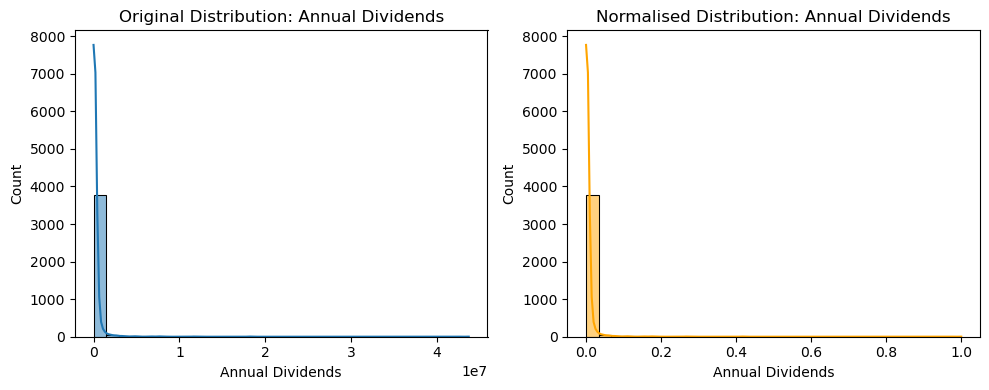

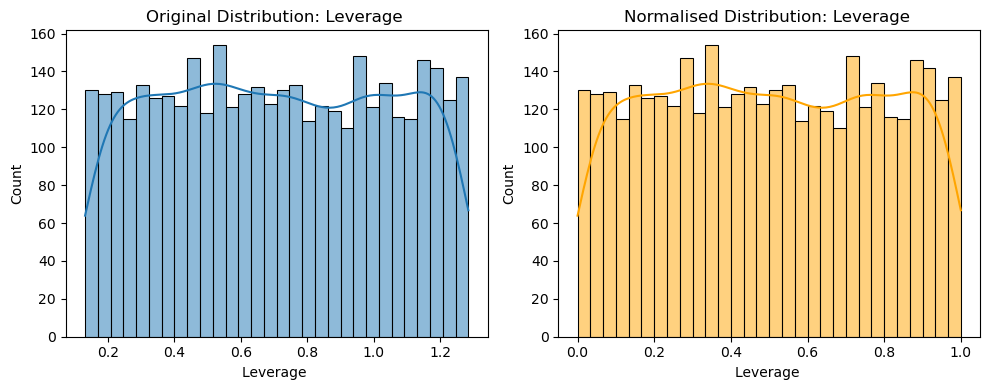

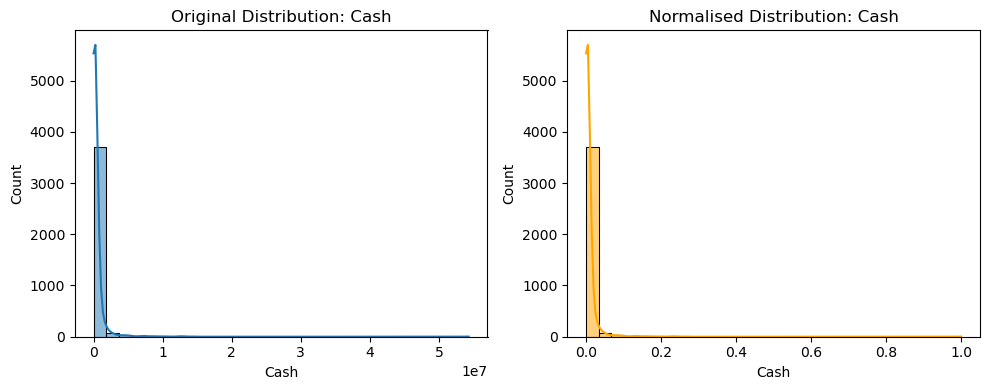

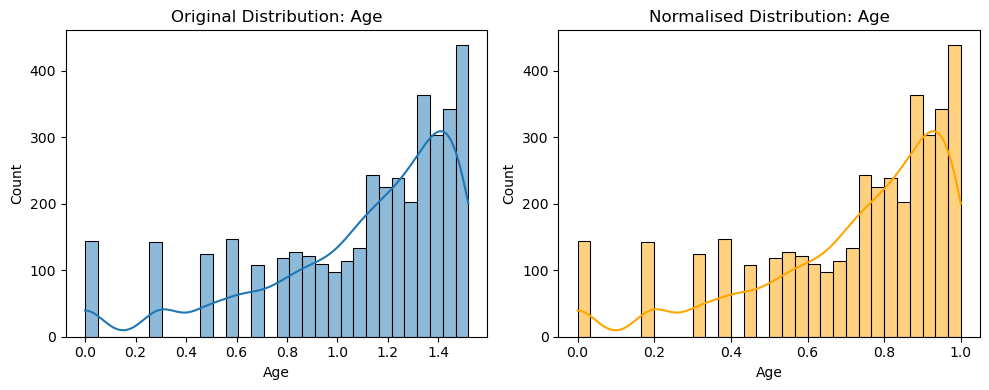

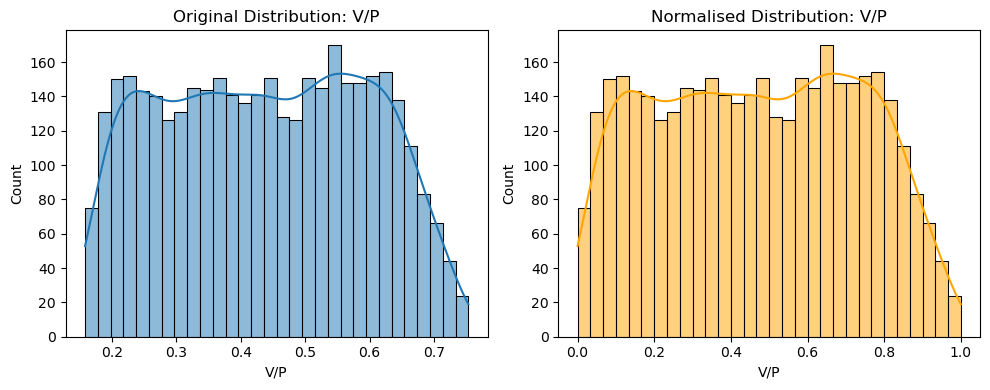

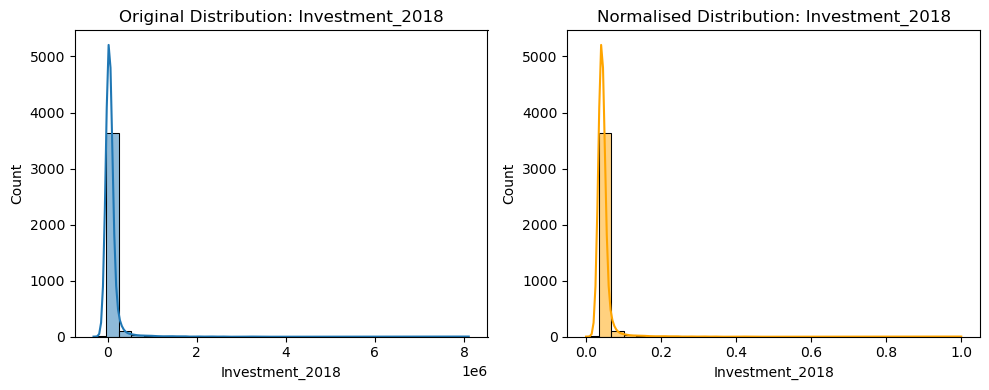

' \nThis plot helps visualise the raw, unscaled data. Features with long tails or skewed peaks \nmay negatively influence models due to outliers or uneven scaling.\nAfter using Min-Max normalisation, all values are scaled between 0 and 1. This helps keep \nall features balanced and makes it easier for models like linear regression to learn quickly. \nKernel Density Estimation (KDE) is then used to show how the data’s shape changes after normalisation, \nwhich helps spot any remaining skew or outliers.\n'

In [20]:
#Task 2(b): Normalisation and Distribution Plots

import matplotlib.pyplot as plt  # Import for plotting
import seaborn as sns  # Import for better visualisations
from sklearn.preprocessing import MinMaxScaler  # Import scaler for normalisation

# Reload the dataset with newly created features
df = pd.read_csv("cleaned_dataset.csv")  # Load the data

# Identify numeric columns to be normalised
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns  # Select only numerical columns

# Create a scaler object for Min-Max normalisation
scaler = MinMaxScaler()

# the original dataset to preserve structure
df_normalised = df.copy()

# Apply Min-Max scaling to all numeric columns
df_normalised[numeric_cols] = scaler.fit_transform(df[numeric_cols])  # Normalise in place

# Loop through each numeric column to create original vs normalised distribution plots
for col in numeric_cols:
    plt.figure(figsize=(10, 4))  # Set the figure size for each plot

    # Plot original feature distribution
    plt.subplot(1, 2, 1)  # First subplot (original)
    sns.histplot(df[col], kde=True, bins=30)  # Histogram with density curve
    plt.title(f"Original Distribution: {col}")  # Add title

    # Plot normalised feature distribution
    plt.subplot(1, 2, 2)  # Second subplot (normalized)
    sns.histplot(df_normalised[col], kde=True, bins=30, color='orange')  # Histogram for normalized data
    plt.title(f"Normalised Distribution: {col}")  # Add title

    # Adjust layout and show plot
    plt.tight_layout()
    plt.show()

''' 
This plot helps visualise the raw, unscaled data. Features with long tails or skewed peaks 
may negatively influence models due to outliers or uneven scaling.
After using Min-Max normalisation, all values are scaled between 0 and 1. This helps keep 
all features balanced and makes it easier for models like linear regression to learn quickly. 
Kernel Density Estimation (KDE) is then used to show how the data’s shape changes after normalisation, 
which helps spot any remaining skew or outliers.
'''

In [3]:
# Import Required Libraries
import pandas as pd  # For handling datasets
import numpy as np  # For numerical operations
from sklearn.linear_model import LinearRegression  # For building the regression model
from sklearn.model_selection import KFold  # For performing k-fold cross-validation
from sklearn.preprocessing import MinMaxScaler  # For feature normalisation
from sklearn.metrics import r2_score  # For calculating R² score
from itertools import combinations  # For generating feature combinations

# Load and Prepare Data 
def load_and_prepare_data():
   
    df = pd.read_csv("finanical_report_2018.csv")  # Load 2018 financial data
    invest = pd.read_csv("Investment_2019.csv").rename(columns={"Investment2019": "Investment_2019"})  # Load 2019 investment data and rename the target column for consistency
    df = pd.merge(df, invest, on="Stock Code", how="left") # Merge datasets using 'Stock Code' as the key
    df.columns = df.columns.str.strip()  # Remove leading/trailing whitespace from all column names    
    df = df.apply(lambda col: pd.to_numeric(col, errors='coerce')) # Convert all values to numeric; invalid values will be replaced with NaN

    # Calculate V/P (Value-to-Price ratio) using the provided formula
    df["V/P"] = ((1 - 1.24*0.12) * df["Book Value"] +
                 1.24 * 1.12 * df["Operating Income after Depreciation"] -
                 1.24 * 0.12 * df["Annual Dividends"]) / df["Market Value of Equity"]

    # Calculate Investment_2018 by subtracting amortisation/depreciation from total investment
    df["Investment_2018"] = df["Total Investment Expenditure"] - df["Amortization and Depreciation"]

    print("Data loaded and prepared successfully.")
    return df  # Return the cleaned and enriched dataset

# Adjusted R² Calculation 
def adjusted_r2(y_true, y_pred, n, p):
    r2 = r2_score(y_true, y_pred)  # Calculate standard R² score
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)  # Return adjusted R² using the formula

# Cross-Validated Adjusted R² 
def cross_val_adj_r2(X, y, model, cv=10):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)  # Initialise 10-fold CV
    scores = []  # To store adjusted R² scores per fold
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]  # Split training/testing features
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]  # Split training/testing targets
        model.fit(X_train, y_train)  # Train model
        y_pred = model.predict(X_test)  # Predict on test data
        scores.append(adjusted_r2(y_test, y_pred, *X_test.shape))  # Append adjusted R²
    return np.mean(scores)  # Return the average adjusted R² across all folds

# Feature Subset Selection 
def select_best_features(data, features, y):
    best_score, best_subset = -np.inf, features  # Initialise with worst possible score
    scaler = MinMaxScaler()  # Create a scaler for normalisation

    print("Evaluating feature subsets for best Adjusted R²...")
    for r in range(5, 8):  # Try subsets of size 5, 6, and 7
        for subset in combinations(features, r):
            X_sub = data[list(subset)].dropna()  # Drop rows with missing values
            y_sub = y.loc[X_sub.index]  # Align target with feature rows
            X_sub_scaled = pd.DataFrame(scaler.fit_transform(X_sub), columns=subset)  # Normalise features
            score = cross_val_adj_r2(X_sub_scaled, y_sub, LinearRegression())  # Evaluate subset
            if score > best_score:  # Update best score if better
                best_score, best_subset = score, list(subset)

    print(f"Best feature subset selected: {best_subset}")
    print(f"Best Adjusted R²: {round(best_score, 4)}")
    return best_subset, best_score  # Return optimal subset and score

# Train Final Model and Predict 
def train_and_predict(df, features, y_col):
    model = LinearRegression()  # Create a regression model
    scaler = MinMaxScaler()  # Create a scaler
    valid = df.dropna(subset=features + [y_col]) # Keep only rows with valid (non-missing) data for training

    X = valid[features]  # Extract training features and target
    y = valid[y_col]
   
    X_scaled = scaler.fit_transform(X)  # Normalise training data
    model.fit(X_scaled, y)  # Train the model on clean data
    X_all = df[features]  # Prepare all rows for prediction
    valid_rows = X_all.dropna().index  # Identify rows with complete data
    df["Predicted_Investment_2019"] = np.nan  # Initialise prediction column
    df.loc[valid_rows, "Predicted_Investment_2019"] = model.predict(scaler.transform(X_all.loc[valid_rows]))  # Make predictions only for valid rows
    print("Predictions generated successfully.")
    return df[["Stock Code", "Investment_2019", "Predicted_Investment_2019"]]  # Return required columns only

df = load_and_prepare_data() # Load and prepare the dataset
required = ["V/P", "Leverage", "Cash", "Age", "Size", "Stock Return", "Investment_2018"] # Define the 7 required independent variables
df = df.dropna(subset=required + ["Investment_2019"]) # Drop any rows with missing values in features or target
best_features, _ = select_best_features(df, required, df["Investment_2019"]) # Select the best subset of features based on Adjusted R²
final_output = train_and_predict(df, best_features, "Investment_2019") # Train the model and generate predictions
final_output.to_csv("new_investment_2019.csv", index=False) # Export the final output to a CSV with only 3 specified columns
print("'new_investment_2019.csv' created with required predictions.")


Data loaded and prepared successfully.
Evaluating feature subsets for best Adjusted R²...
Best feature subset selected: ['V/P', 'Leverage', 'Size', 'Stock Return', 'Investment_2018']
Best Adjusted R²: 0.5424
Predictions generated successfully.
File 'new_investment_2019.csv' created with required predictions.
